# MAPED Acquisition

Acquire five 4D-STEM scans at different beam tilts, register and average them with quantEM, then recover spatial lattice-parameter, crystal-rotation, and tilt-sensitive maps. The digital twin creates a local ASE silicon cell and runs a real abTEM multislice calculation at every silicon scan point.

### Run the servers

Install the abTEM simulation extra once, then start the silicon lamella twin from the repository root:

```bash
uv sync --extra diffraction
uv run startup_scripts/run_servers.py --yaml configs/digital_twin_tilt.yaml
```

Use `uv run startup_scripts/run_servers.py` instead for the microscope.

### Imports

In [1]:
import json
import os

import matplotlib.pyplot as plt
import numpy as np
import tango
from quantem.core.datastructures import Dataset4dstem
from quantem.core.utils.imaging_utils import cross_correlation_shift
from tiled.client import from_uri

%matplotlib ipympl

### Ping servers

In [2]:
DB_HOST = "127.0.0.1"  # digital twin
# DB_HOST = "10.46.217.241"  # microscope
DB_PORT = 9094

os.environ["TANGO_HOST"] = f"{DB_HOST}:{DB_PORT}"

scan = tango.DeviceProxy("asyncroscopy/scan/default")
microscope = tango.DeviceProxy("asyncroscopy/instrument/default")
data = tango.DeviceProxy("asyncroscopy/data/default")

for proxy in [scan, microscope, data]:
    proxy.set_timeout_millis(3_600_000)
    proxy.ping()
    print(proxy.name(), proxy.state())

asyncroscopy/scan/default ON
asyncroscopy/instrument/default ON
asyncroscopy/data/default ON


### Set Tiled Client

In [3]:
config = json.loads(data.get_config())
client = from_uri(config.get("uri"))
print("Tiled keys:", list(client))

Tiled keys: ['stem_image_HAADF_20260617T113100890911.h5', 'spectrum_eds_20260617T113333863968.h5', 'spectrum_eds_20260617T113333946998.h5', 'spectrum_eds_20260617T113334018225.h5', 'spectrum_eds_20260617T113334090072.h5', 'spectrum_eds_20260617T113334158870.h5', 'stem_image_HAADF_20260619T193537178014.h5', 'stem_image_HAADF_20260619T193629581856.h5', 'diffraction_BM-Ceta_20260619T193631500749.h5', 'diffraction_BM-Ceta_20260619T193631852562.h5', 'diffraction_BM-Ceta_20260619T193635044869.h5', 'diffraction_BM-Ceta_20260619T193638201360.h5', 'diffraction_BM-Ceta_20260619T193641355383.h5', 'stem_image_HAADF_20260619T193755955267.h5', 'stem_image_HAADF_20260619T194030676929.h5', 'stem_image_HAADF_20260619T194736076730.h5', 'stem_image_HAADF_20260619T195116284309.h5', 'stem_image_HAADF_20260619T195724455994.h5', 'diffraction_BM-Ceta_20260619T195742736439.h5', 'diffraction_BM-Ceta_20260619T195810018189.h5', 'diffraction_BM-Ceta_20260619T195848501752.h5', 'diffraction_BM-Ceta_20260619T19590691

### Configure 4D-STEM acquisition

Every digital-twin scan point is an independent ASE/abTEM multislice calculation, so the example uses a small scan. Increase `scan.imsize` for the microscope or for a longer simulation. `beam_tilt_radius` is in radians and should be calibrated for the microscope.

In [4]:
instrument_parameters = json.loads(microscope.get_parameters())
is_multislice_twin = instrument_parameters.get("sample") == "bulk silicon FIB lamella"

scan.dwell_time = 500e-6
scan.imsize = 12 if is_multislice_twin else 128
scan.scan_region = [0, 0, 1, 1]

beam_tilt_radius = 40e-3
beam_tilts = np.array([
    [0, 0],
    [beam_tilt_radius, 0],
    [0, beam_tilt_radius],
    [-beam_tilt_radius, 0],
    [0, -beam_tilt_radius],
])

print("Screen current (pA):", microscope.get_screen_current())
print("Beam tilts (mrad):")
print(beam_tilts * 1e3)
print("Scan size:", scan.imsize)
if is_multislice_twin:
    print("Multislice supercell:", instrument_parameters["multislice_supercell"])

Screen current (pA): 50.0
Beam tilts (mrad):
[[  0.   0.]
 [ 40.   0.]
 [  0.  40.]
 [-40.   0.]
 [  0. -40.]]
Scan size: 12
Multislice supercell: [4, 4, 8]


### Acquire five beam tilts

In [5]:
starting_beam_tilt = np.asarray(microscope.get_beam_tilt(), dtype=float)
maped_keys = []

try:
    for beam_tilt in beam_tilts:
        microscope.set_beam_tilt(beam_tilt.tolist())
        key = microscope.acquire_scanned_data_advanced()
        maped_keys.append(key)
        print(f"{beam_tilt * 1e3} mrad -> {key}")
finally:
    microscope.set_beam_tilt(starting_beam_tilt.tolist())

[0. 0.] mrad -> stem_data_BM-Ceta_20260808T063127936585.h5
[40.  0.] mrad -> stem_data_BM-Ceta_20260808T063144531371.h5
[ 0. 40.] mrad -> stem_data_BM-Ceta_20260808T063156990537.h5
[-40.   0.] mrad -> stem_data_BM-Ceta_20260808T063211244410.h5
[  0. -40.] mrad -> stem_data_BM-Ceta_20260808T063224521992.h5


### Load the 4D-STEM datasets with quantEM

In [6]:
datacubes = [np.asarray(client[key]["stem_data"].read()) for key in maped_keys]
datasets = [
    Dataset4dstem.from_array(cube, name=f"MAPED tilt {index}")
    for index, cube in enumerate(datacubes)
]

truth_names = [
    "lattice_parameter_angstrom",
    "bond_distance_angstrom",
    "crystal_rotation_deg",
    "crystal_tilt_x_mrad",
    "crystal_tilt_y_mrad",
]
has_simulation_truth = "simulation" in list(client[maped_keys[0]])
truth_maps = [
    {name: np.asarray(client[key]["simulation"][name].read()) for name in truth_names}
    for key in maped_keys
] if has_simulation_truth else []

print("Dataset shape:", datasets[0].shape)
print("Simulation truth available:", has_simulation_truth)

Dataset shape: (12, 12, 32, 32)
Simulation truth available: True


### Align reciprocal space

Align each mean diffraction pattern to the untilted scan. The quantEM correlation is refined to subpixel precision and applied with a Fourier shift to avoid rounding away small reciprocal changes.

In [7]:
reference_dp = datasets[0].get_dp_mean(attach=False).array
q_shifts = np.asarray([
    cross_correlation_shift(
        reference_dp,
        dataset.get_dp_mean(attach=False).array,
        upsample_factor=4,
    )
    for dataset in datasets
])
q_shifts -= q_shifts[0]
q_frequency_y = np.fft.fftfreq(reference_dp.shape[0])[:, None]
q_frequency_x = np.fft.fftfreq(reference_dp.shape[1])[None, :]
reciprocal_aligned = []
for dataset, shift in zip(datasets, q_shifts):
    phase = np.exp(
        -2j * np.pi * (q_frequency_y * shift[0] + q_frequency_x * shift[1])
    )
    aligned = np.fft.ifft2(
        np.fft.fft2(dataset.array, axes=(-2, -1)) * phase,
        axes=(-2, -1),
    ).real
    reciprocal_aligned.append(np.clip(aligned, 0, None).astype(np.float32))
print("Reciprocal-space shifts (row, column):")
print(q_shifts)

Reciprocal-space shifts (row, column):
[[0.         0.        ]
 [0.24763714 0.42769918]
 [0.43378581 0.36536757]
 [0.36857377 0.32354405]
 [0.20571709 0.1524807 ]]


### Align real space and average

quantEM virtual dark-field images provide the real-space registration signal. The aligned cubes are cropped to remove wrapped edges before averaging.

In [8]:
dp_size = min(reciprocal_aligned[0].shape[-2:])
dp_center = tuple((np.array(reciprocal_aligned[0].shape[-2:]) - 1) / 2)
aligned_datasets = [Dataset4dstem.from_array(cube) for cube in reciprocal_aligned]
virtual_df = [
    dataset.get_virtual_image(
        mode="annular",
        geometry=(dp_center, (0.15 * dp_size, 0.45 * dp_size)),
        attach=False,
    ).array
    for dataset in aligned_datasets
]

real_shifts = np.asarray([
    cross_correlation_shift(virtual_df[0], image, upsample_factor=4)
    for image in virtual_df
])
real_shifts -= real_shifts[0]
real_frequency_y = np.fft.fftfreq(virtual_df[0].shape[0])[:, None]
real_frequency_x = np.fft.fftfreq(virtual_df[0].shape[1])[None, :]
real_aligned = []
for cube, shift in zip(reciprocal_aligned, real_shifts):
    phase = np.exp(
        -2j * np.pi * (real_frequency_y * shift[0] + real_frequency_x * shift[1])
    )[:, :, None, None]
    aligned = np.fft.ifft2(
        np.fft.fft2(cube, axes=(0, 1)) * phase,
        axes=(0, 1),
    ).real
    real_aligned.append(np.clip(aligned, 0, None).astype(np.float32))

margin_y, margin_x = np.ceil(np.max(np.abs(real_shifts), axis=0)).astype(int)
row_slice = slice(margin_y, None if margin_y == 0 else -margin_y)
column_slice = slice(margin_x, None if margin_x == 0 else -margin_x)
maped_array = np.mean(
    [cube[row_slice, column_slice] for cube in real_aligned],
    axis=0,
)
maped = Dataset4dstem.from_array(maped_array, name="MAPED average")

print("Real-space shifts (row, column):")
print(real_shifts)
print("MAPED shape:", maped.shape)

Real-space shifts (row, column):
[[ 0.          0.        ]
 [ 0.0728884  -0.66269416]
 [ 0.07813274  0.04263465]
 [ 1.21831461  0.93312364]
 [ 0.2233073   0.11041007]]
MAPED shape: (8, 10, 32, 32)


### Inspect the MAPED result

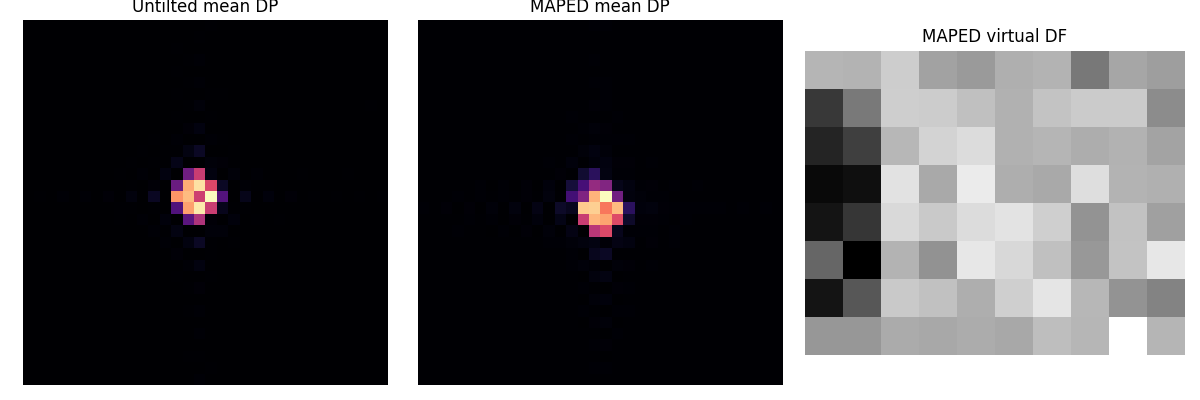

In [9]:
maped_df = maped.get_virtual_image(
    mode="annular",
    geometry=(dp_center, (0.15 * dp_size, 0.45 * dp_size)),
    attach=False,
).array

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(np.log1p(reference_dp), cmap="magma")
axes[0].set_title("Untilted mean DP")
axes[1].imshow(np.log1p(maped.dp_mean.array), cmap="magma")
axes[1].set_title("MAPED mean DP")
axes[2].imshow(maped_df, cmap="gray")
axes[2].set_title("MAPED virtual DF")
for ax in axes:
    ax.axis("off")
plt.tight_layout()

### Locate Bragg disks and form virtual detectors

Find the strongest first-order disk in each quadrant of the MAPED mean pattern. quantEM then integrates the same four detector masks at every probe position.

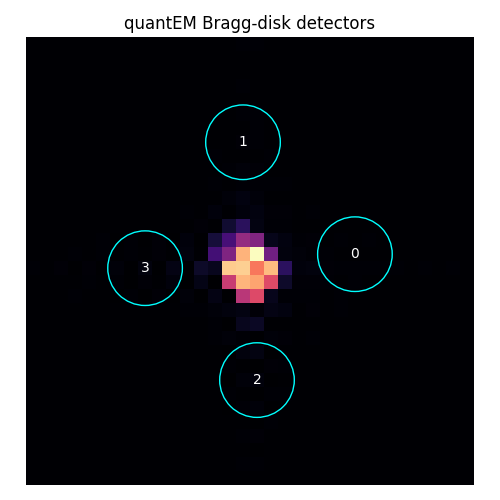

In [10]:
mean_dp = maped.get_dp_mean(attach=False).array
q_row, q_column = np.indices(mean_dp.shape)
q_radius = np.hypot(q_row - dp_center[0], q_column - dp_center[1])
q_pixel_size_mrad = (
    2 * instrument_parameters.get("diffraction_max_angle_mrad", 60) / dp_size
)
disk_radius = max(1.5, 1.25 * instrument_parameters.get("convergence_angle_mrad", 8) / q_pixel_size_mrad)
search_pattern = np.log1p(mean_dp).copy()
search_pattern[(q_radius < 2.5 * disk_radius) | (q_radius > 0.45 * dp_size)] = -np.inf
peak_candidates = []
for _ in range(8):
    peak = np.unravel_index(np.argmax(search_pattern), mean_dp.shape)
    peak_candidates.append(peak)
    exclusion = np.hypot(q_row - peak[0], q_column - peak[1]) < 1.5 * disk_radius
    search_pattern[exclusion] = -np.inf

offsets = np.asarray(peak_candidates, dtype=float) - dp_center
first_offset = offsets[0]
remaining = [
    index
    for index in range(1, len(offsets))
    if min(
        np.linalg.norm(offsets[index] - first_offset),
        np.linalg.norm(offsets[index] + first_offset),
    ) > 1.5 * disk_radius
]
perpendicularity = [
    abs(first_offset[0] * offsets[index, 1] - first_offset[1] * offsets[index, 0])
    / (np.linalg.norm(first_offset) * np.linalg.norm(offsets[index]))
    for index in remaining
]
second_offset = offsets[remaining[int(np.argmax(perpendicularity))]]
center = np.asarray(dp_center)
peak_positions = [
    center - first_offset,
    center - second_offset,
    center + second_offset,
    center + first_offset,
]

detector_masks = [
    np.hypot(q_row - row, q_column - column) <= disk_radius
    for row, column in peak_positions
]
bragg_images = [
    maped.get_virtual_image(mask=mask, name=f"Bragg {index}", attach=False).array
    for index, mask in enumerate(detector_masks)
]

fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(np.log1p(mean_dp), cmap="magma")
for index, (row, column) in enumerate(peak_positions):
    ax.add_patch(plt.Circle((column, row), disk_radius, fill=False, color="cyan"))
    ax.text(column, row, str(index), color="white", ha="center", va="center")
ax.set_title("quantEM Bragg-disk detectors")
ax.axis("off")
plt.tight_layout()

### Recover lattice parameter and crystal rotation

Measure each disk centroid at every real-space pixel. Opposite-disk separation gives reciprocal spacing, hence lattice parameter; the angle of that vector gives local in-plane crystal rotation.

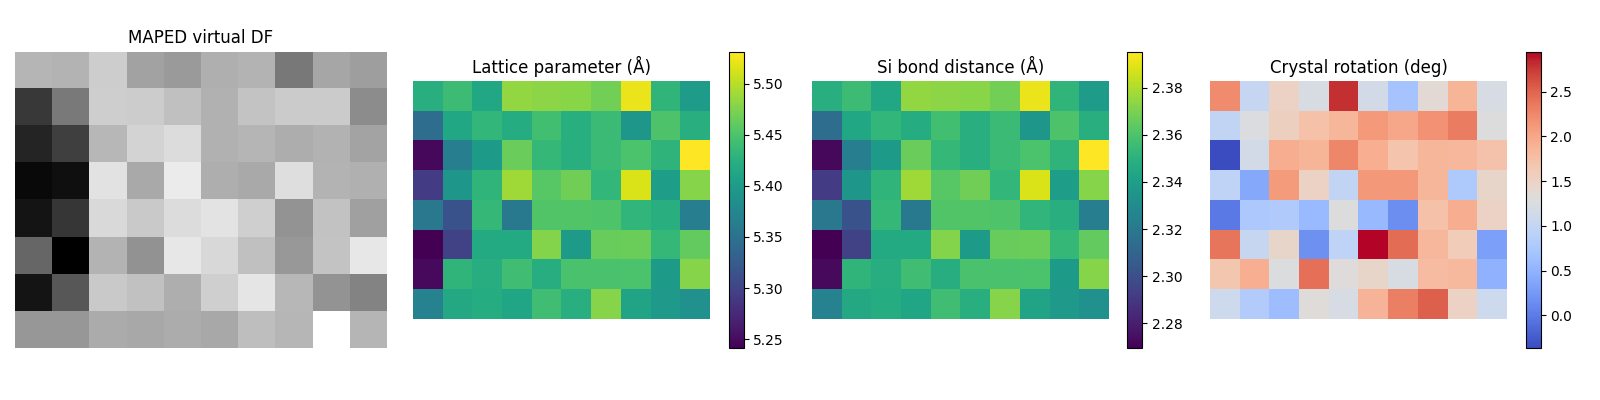

In [11]:
centroids = []
for mask in detector_masks:
    weights = maped_array * mask
    intensity = weights.sum(axis=(-2, -1)) + np.finfo(float).eps
    centroid_row = (weights * q_row).sum(axis=(-2, -1)) / intensity
    centroid_column = (weights * q_column).sum(axis=(-2, -1)) / intensity
    centroids.append(np.stack([centroid_row, centroid_column], axis=-1))

g1 = 0.5 * (centroids[3] - centroids[0])
g2 = 0.5 * (centroids[2] - centroids[1])
g_magnitude = 0.5 * (
    np.linalg.norm(g1, axis=-1) + np.linalg.norm(g2, axis=-1)
)
bragg_sum = np.sum(bragg_images, axis=0)
valid = bragg_sum > 0.1 * np.nanmax(bragg_sum)
reference_g = np.nanmedian(g_magnitude[valid])
reference_lattice = instrument_parameters.get("silicon_lattice_parameter_angstrom", 5.431)
lattice_parameter_map = reference_lattice * reference_g / g_magnitude
bond_distance_map = lattice_parameter_map * np.sqrt(3) / 4
rotation_raw = np.degrees(np.arctan2(g1[..., 0], g1[..., 1]))
rotation_delta = (rotation_raw - np.nanmedian(rotation_raw[valid]) + 180) % 360 - 180
crystal_rotation_map = instrument_parameters.get("crystal_rotation_deg", 0) + rotation_delta
lattice_parameter_map[~valid] = np.nan
crystal_rotation_map[~valid] = np.nan

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
images = [maped_df, lattice_parameter_map, bond_distance_map, crystal_rotation_map]
titles = [
    "MAPED virtual DF", "Lattice parameter (Å)",
    "Si bond distance (Å)", "Crystal rotation (deg)",
]
cmaps = ["gray", "viridis", "viridis", "coolwarm"]
for ax, image, title, cmap in zip(axes, images, titles, cmaps):
    plot = ax.imshow(image, cmap=cmap)
    ax.set_title(title)
    ax.axis("off")
    if title != "MAPED virtual DF":
        fig.colorbar(plot, ax=ax, shrink=0.8)
plt.tight_layout()

### Validate against the multislice inputs

The twin saves the exact lattice parameter, nearest-neighbor bond distance, and local ASE rotations used to construct every abTEM potential. These are validation data, not inputs to the recovery above.

Lattice RMSE (Å): 0.04181183561139431
Rotation RMSE (deg): 1.3319485216414766


/var/folders/1h/36qxtl8567zdjv8nzdn4fzrr0000gn/T/ipykernel_19914/3748457018.py:8: RuntimeWarning: Mean of empty slice
  aligned_truth[name] = np.nanmean(shifted_maps, axis=0)


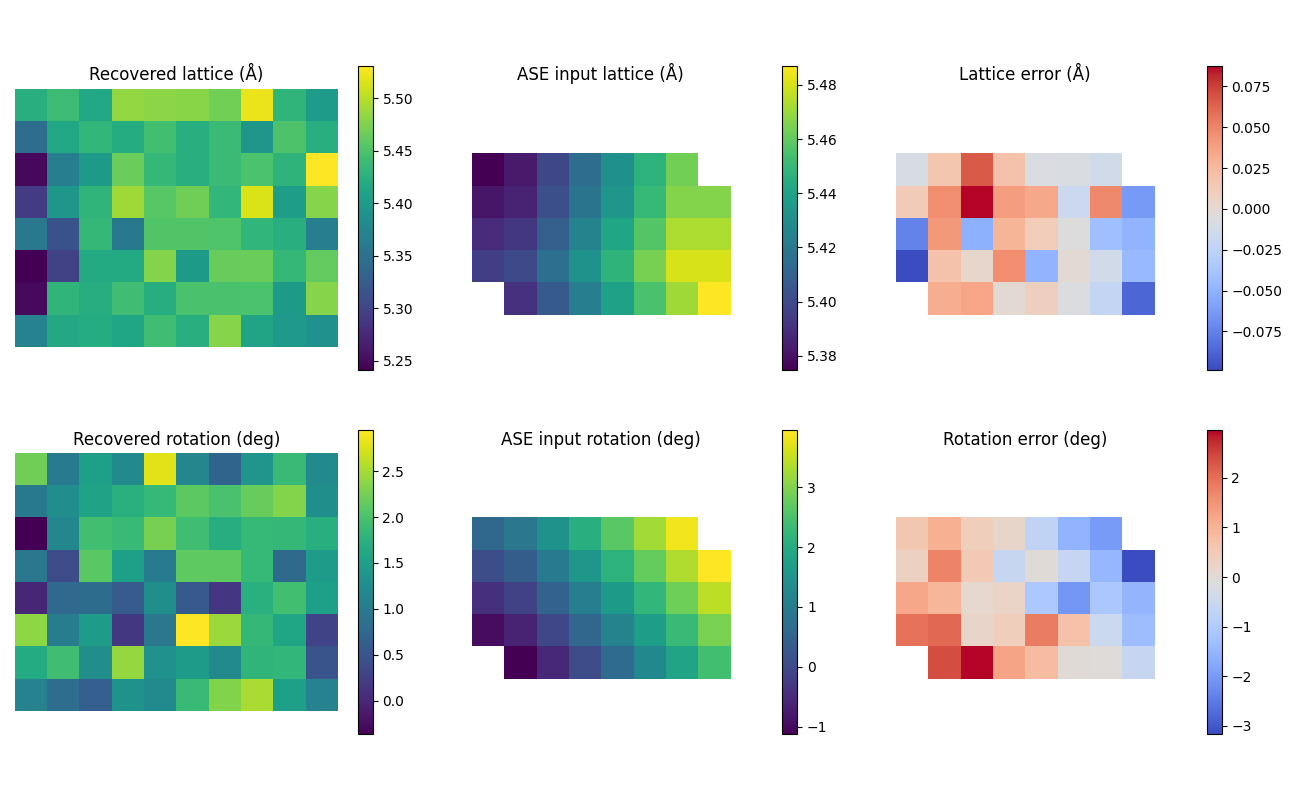

In [12]:
if has_simulation_truth:
    aligned_truth = {}
    for name in truth_names:
        shifted_maps = [
            np.roll(values[name], np.rint(shift).astype(int), axis=(0, 1))[row_slice, column_slice]
            for values, shift in zip(truth_maps, real_shifts)
        ]
        aligned_truth[name] = np.nanmean(shifted_maps, axis=0)

    truth_lattice = aligned_truth["lattice_parameter_angstrom"]
    truth_rotation = aligned_truth["crystal_rotation_deg"]
    comparison = valid & np.isfinite(truth_lattice)
    lattice_error = lattice_parameter_map - truth_lattice
    rotation_error = crystal_rotation_map - truth_rotation

    fig, axes = plt.subplots(2, 3, figsize=(13, 8))
    fields = [
        lattice_parameter_map, truth_lattice, lattice_error,
        crystal_rotation_map, truth_rotation, rotation_error,
    ]
    titles = [
        "Recovered lattice (Å)", "ASE input lattice (Å)", "Lattice error (Å)",
        "Recovered rotation (deg)", "ASE input rotation (deg)", "Rotation error (deg)",
    ]
    for ax, image, title in zip(axes.flat, fields, titles):
        plot = ax.imshow(image, cmap="coolwarm" if "error" in title.lower() else "viridis")
        ax.set_title(title)
        ax.axis("off")
        fig.colorbar(plot, ax=ax, shrink=0.75)
    plt.tight_layout()

    print("Lattice RMSE (Å):", np.sqrt(np.nanmean(lattice_error[comparison] ** 2)))
    print("Rotation RMSE (deg):", np.sqrt(np.nanmean(rotation_error[comparison] ** 2)))

### Tilt-sensitive Friedel-pair contrast

Opposite Bragg-disk intensity differences are sensitive to local crystal tilt through dynamical multislice scattering. MAPED's symmetric beam tilts suppress the illumination-tilt contribution while retaining the specimen field.

Rows: Friedel signals; columns: ASE x/y tilt correlation
[[ 0.09367896 -0.27189629]
 [ 0.25849659 -0.13845091]]


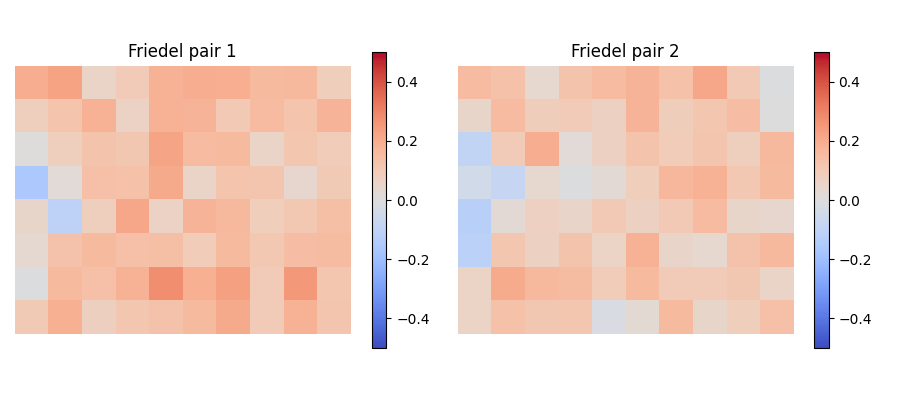

In [13]:
friedel_1 = (bragg_images[3] - bragg_images[0]) / (bragg_images[3] + bragg_images[0] + 1e-12)
friedel_2 = (bragg_images[2] - bragg_images[1]) / (bragg_images[2] + bragg_images[1] + 1e-12)
friedel_1[~valid] = np.nan
friedel_2[~valid] = np.nan

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
for ax, image, title in zip(axes, [friedel_1, friedel_2], ["Friedel pair 1", "Friedel pair 2"]):
    plot = ax.imshow(image, cmap="coolwarm", vmin=-0.5, vmax=0.5)
    ax.set_title(title)
    ax.axis("off")
    fig.colorbar(plot, ax=ax, shrink=0.8)
plt.tight_layout()

if has_simulation_truth:
    truth_tilts = [
        aligned_truth["crystal_tilt_x_mrad"],
        aligned_truth["crystal_tilt_y_mrad"],
    ]
    signals = [friedel_1, friedel_2]
    correlations = np.array([
        [np.corrcoef(signal[comparison], tilt[comparison])[0, 1] for tilt in truth_tilts]
        for signal in signals
    ])
    print("Rows: Friedel signals; columns: ASE x/y tilt correlation")
    print(correlations)